## Change root directory

In [1]:
import os
root_dir = os.path.dirname(os.path.abspath(''))
os.chdir(root_dir)
print(f"Directory changed to: {os.getcwd()}")

Directory changed to: /home/bespi123/git/helmholtzCoilsDesigner


## Import libraries

In [2]:
import time
import numpy as np
import pandas as pd
from src import helmCoils_simulator as sim
from src import plotMagneticField as hplot
from src import helmCoils_optmizer as opt
import matplotlib.pyplot as plt
import plotly.graph_objs as go

## Define Simulation Parameters

In [3]:
number_of_spires = 2
size_length =  1.05
distance_among_spires = 0.59
turns = [30, 30]
current = 1 
rotation_matrix = np.eye(3)
X_coil = sim.CoilParameters(number_of_spires, size_length, distance_among_spires, turns, current, rotation_matrix)

# Simulation settings
parallel_coils = 150
batch_Size = 120
grid_length_size = 0.01 #Space among evaluation points
num_seg = 100           #Numer of segments 

## Plot coils

In [4]:
##Spawn spires
spires_x_sq = X_coil.square_spires(num_seg)

f0 = None
f0 = hplot.plot_spires(f0, spires_x_sq, color='black', row=None, col=None)

# Plot the square spires
f0.show()

In [5]:
X, Y, Z = sim.generate_range([0,0],[0,0],[0,0], step_size_x = grid_length_size)

hplot.plot_grid(X, Y, Z, f0)

## Optimization Problem

In [6]:
# Make sure that Ax, X, Y, Z, and test_3 functions are properly defined in your environment.
optimizer = opt.Source_optimizer(
    desired_magField = 45839.86895741893*1e-9,          # T
    coil = X_coil,
    spires = spires_x_sq,
    fixed_V_limit = 12,
    max_N = 1000,
    max_I = 10,
    population = 500,
    generations = 3000,
    mutation = 0.8
)
result = optimizer.optimize()

gen	nevals	min    	avg    
0  	499   	20.9871	8160.39
1  	448   	14.1323	6393.83
2  	454   	15.18  	5314.41
3  	444   	9.64174	4263.94
4  	459   	6.76573	3056.21
5  	452   	6.76573	1506.11
6  	457   	6.76573	447.844
7  	455   	6.76573	355.038
8  	447   	6.76573	433.004
9  	453   	6.76573	451.061
10 	438   	6.76573	278.93 
11 	459   	6.56599	307.884
12 	434   	6.56599	447.472
13 	436   	6.56599	617.311
14 	442   	6.49753	747.153
15 	449   	5.63952	927.144
16 	442   	5.57597	797.008
17 	441   	5.57597	756.965
18 	451   	5.57597	866.895
19 	450   	5.57597	826.752
20 	445   	5.57597	576.522
21 	464   	5.57597	706.333
22 	452   	5.57597	706.098
23 	440   	5.57597	706.044
24 	454   	5.57597	806.154
25 	454   	5.57597	796.067
26 	449   	5.57597	806.095
27 	453   	5.57597	786.125
28 	451   	5.57597	886.092
29 	457   	5.57597	766.033
30 	439   	5.57597	896.116
31 	449   	5.57597	736.048
32 	452   	5.57597	776.121
33 	455   	5.57597	716.072
34 	433   	5.57597	696.032
35 	454   	5.57597	726.088
3

## Plot optimization performance

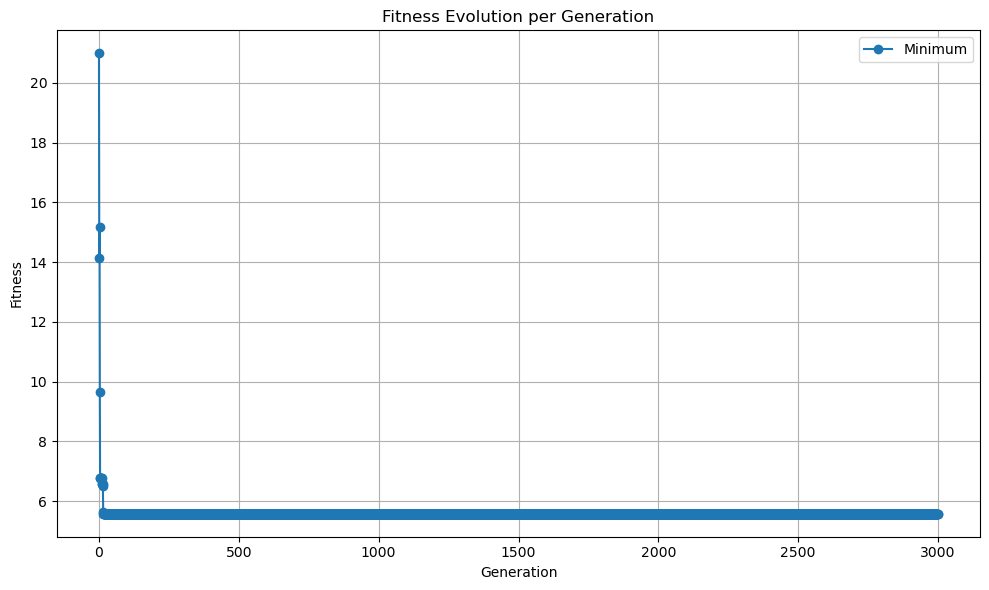

In [7]:
a = pd.DataFrame(result[3])
# Create plot with two curves
plt.figure(figsize=(10, 6))
plt.plot(a['gen'], a['min'], label='Minimum', marker='o', linestyle='-', linewidth=1.5)
#plt.plot(a['gen'], a['avg'], label='Average', marker='x', linestyle='--', linewidth=1.5)

# Add labels and details
plt.title("Fitness Evolution per Generation")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Sensivity analisys

## Initial Conditions Analisys

In [8]:
results = []

for i in range(1, 100):
    initial_values = np.array([
        np.random.uniform(0, 1000),
        np.random.uniform(0, 10)   
    ])

    optimizer = opt.Source_optimizer(
        desired_magField = 45839.86895741893*1e-9,          # T
        coil = X_coil,
        spires = spires_x_sq,
        fixed_V_limit = 12,
        max_N = 1000,
        max_I = 10,
        population = 1000,
        generations = 200,
        mutation = 0.8,
        penalty=5000,
        initial_values = initial_values
    )
    
    start_time = time.time()
    result = optimizer.optimize()
    elapsed_time = time.time() - start_time

    # Suponiendo que 'result' tiene un atributo 'final_error'
    results.append({
        'initial_values': initial_values,
        'results': result,
        'time_s': elapsed_time
    })

# Mostrar resultados
df = pd.DataFrame(results)

# Save dataframe as csv file
df.to_csv('sensivity_analisys_2.csv', index=False)  

gen	nevals	min    	avg    
0  	999   	15.4935	8064.36
1  	893   	15.3469	6351.55
2  	915   	9.18985	5323.85
3  	902   	9.27683	4394.34
4  	906   	7.03347	3222.26
5  	894   	6.839  	1548.57
6  	882   	6.46142	399.327
7  	903   	6.22721	395.035
8  	909   	5.63952	448.684
9  	919   	5.70341	766.582
10 	906   	5.57597	454.497
11 	896   	5.57597	417.706
12 	890   	5.57597	386.981
13 	901   	5.57597	371.481
14 	899   	5.57597	526.282
15 	902   	5.57597	651.178
16 	891   	5.57597	636.081
17 	888   	5.57597	766.063
18 	894   	5.57597	636.071
19 	902   	5.57597	746.082
20 	909   	5.57597	741.058
21 	899   	5.57597	686.004
22 	920   	5.57597	746.023
23 	905   	5.57597	761.053
24 	894   	5.57597	806.132
25 	900   	5.57597	786.174
26 	898   	5.57597	806.087
27 	893   	5.57597	761.127
28 	899   	5.57597	776.083
29 	887   	5.57597	756.064
30 	889   	5.57597	801.072
31 	914   	5.57597	781.026
32 	890   	5.57597	686.057
33 	901   	5.57597	906.13 
34 	891   	5.57597	791.096
35 	901   	5.57597	756.083
3

## Plot Sensivity Analisys results

In [9]:
# Assuming df is your DataFrame and has the columns 'initial_values' and 'results'
init_1 = [a[0] for a in df['initial_values']]
init_2 = [a[1] for a in df['initial_values']]
min_errors = [t[2] for t in df['results']]

fig = go.Figure(data=[go.Scatter3d(
    x=init_1,
    y=init_2,
    z=min_errors,
    mode='markers',
    marker=dict(
        size=5,
        color=min_errors,  # color by cost function value
        colorscale='Viridis',
        opacity=0.8
    )
)])

fig.update_layout(
    width=900,    # Ancho en píxeles
    height=700,   # Alto en píxeles
    scene=dict(
        xaxis_title='I (A)',
        yaxis_title='N (-)',
        zaxis_title='Power (W)'
    ),
    title="Sensivity Analisys"
)

fig.show()